# 07 - Model Comparison

Compare Random Forest, SVM, and hybrid models using the corrected logical label order.


In [1]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
os.makedirs('../../outputs/plots', exist_ok=True)

X_train, X_test, y_train, y_test = joblib.load('../../models/splits.pkl')
le = joblib.load('../../models/label_encoder.pkl')
rf = joblib.load('../../models/random_forest_model.pkl')
svm = joblib.load('../../models/svm_model.pkl')
stacking = joblib.load('../../models/hybrid_stacking_model.pkl')
voting = joblib.load('../../models/hybrid_voting_model.pkl')

class_names = list(le.classes_)
print('Classes:', class_names)


Classes: [np.str_('Healthy'), np.str_('Moderate Stress'), np.str_('High Stress')]


In [2]:
results = []
for name, model in [
    ('Random Forest', rf),
    ('SVM', svm),
    ('Hybrid Voting', voting),
    ('Hybrid Stacking', stacking),
]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results.append({
        'Model': name,
        'Train Accuracy': round(train_acc * 100, 2),
        'Test Accuracy': round(test_acc * 100, 2),
        'Generalization Gap': round((train_acc - test_acc) * 100, 2),
    })

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results_df


,Model,Train Accuracy,Test Accuracy,Generalization Gap
0,Hybrid Stacking,93.65,91.67,1.98
1,Hybrid Voting,86.98,82.50,4.48
2,Random Forest,75.21,74.17,1.04
3,SVM,75.94,73.75,2.19


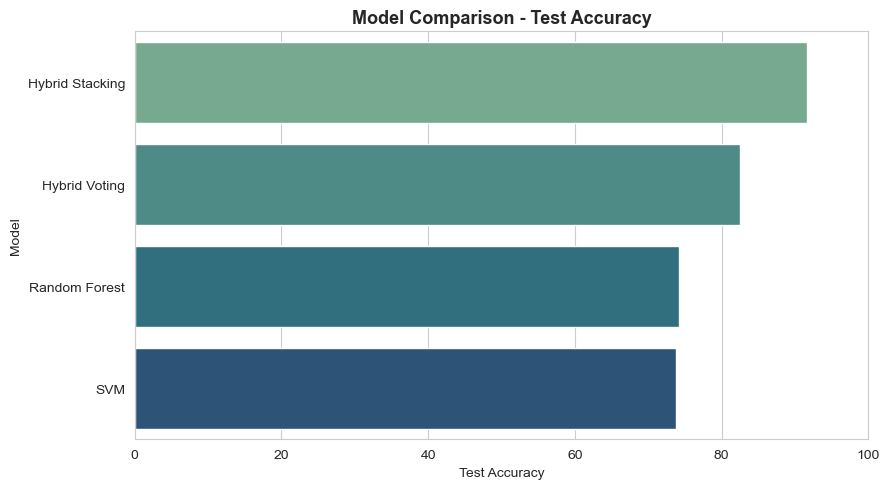

In [3]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x='Test Accuracy', y='Model', hue='Model', legend=False, palette='crest')
plt.title('Model Comparison - Test Accuracy', fontsize=13, fontweight='bold')
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig('../../outputs/plots/model_comparison.png', dpi=150)
plt.show()
